# <u>**Data Preprocessing and Training**</u>

## **1. Data Parsing and Extraction**

Before using this notebook, the training images and masks must be created and stored in an SqLite database file
as described below

### **Program**: <span style="color:green;">**sqlite_dicom2.py**</span>

- **Input**: Data Directory containing patient info
- **Output**: an Sqlite3 database containing selected structures 
(currently by default sag images of the bladder midline and one layer to the left and right, 3 layers removed)

**Usage notes**: 
1. One file per patient, with all sequences in the zip file
2. Place all the zip files in a single directory
3. Launch sqlite_dicom2.py and select the director containing the zip files
4. Enter a name for the sqlite database. It will be stored in the data directory.

___

## **2. Database Parsing and Modification**

After the creation of the database, it can be beneficial to parse through the images
created and delete spurious ones. This can be done as follows:

### **Program**: <span style="color:yellow;">sqlite_viewer.py</span>

The database can be viewed and modified.
**Keys**: 
- m : show mask on/off
- d : delete current image and mask from database 
- arrow keys : move through the images
___

# Start of the program

In [1]:
# import the required modules
from sqlitedata import SqliteData
# from sklearnex import patch_sklearn
import numpy as np
import pandas as pd
# patch_sklearn()


## **3. Load the Data**

- Use the sqlite database constructed during the parsing & extraction via the sqlite_dicom2 tool of the DICOM files 

In [2]:
# RECTUM
dbfile = 'images_rectum.sqlite'
# dbfile = '/media/peter/videodump/md_data/images_rectum.sqlite'
# dbfile = '/media/peter/data/md_data/processed/images_rectum.sqlite'
db = SqliteData(dbfile)
images,masks,pat_ids = db.get_images_and_masks('rectum')

In [3]:
# create a pandas dataframe with the patient ids, images and masks
df = pd.DataFrame({'pat_id':pat_ids,'images':images,'masks':masks})

### View Information about the Database size

And visualize a sample entry

In [4]:
# print(f'Number of images: {len(images)}, Number of masks: {len(masks)}')
# print(f"Number of unique patients: {len(set(pat_ids))}")

# number of images in total
n_images = df.shape[0]
# number of unique patients
n_patients = df['pat_id'].nunique()
# number of images per patient
n_images_per_patient_df = df.groupby('pat_id').size()
max_images_per_patient = n_images_per_patient_df.max()
min_images_per_patient = n_images_per_patient_df.min()
print(f"Number of images: {n_images}")
print(f"Number of unique patients: {n_patients}")
print(f"Avg. number of images per patient: {n_images_per_patient_df.mean():.2f}")
print(f"Max. number of images per patient: {max_images_per_patient}, patient id: {n_images_per_patient_df.idxmax()}")
print(f"Min. number of images per patient: {min_images_per_patient}, patient id: {n_images_per_patient_df.idxmin()}")


Number of images: 2142
Number of unique patients: 129
Avg. number of images per patient: 16.60
Max. number of images per patient: 30, patient id: P044
Min. number of images per patient: 12, patient id: P017


In [5]:
# close the database
db.close()

## **4. Data Preprocessing**

1. Analyse the imported images to eliminate problem files (wrong image dimensions)

In [6]:
# Using the dataframe, print unique image sizes by checking img.shape for each image, group by result and count
df['image_shape'] = df['images'].apply(lambda x: x.shape)
image_shape_counts = df.groupby('image_shape').size()

In [7]:
# print unique image sizes
print(f"Unique image sizes: ")
for entry in image_shape_counts.index:
    print(f"{entry}: {image_shape_counts[entry]}")

Unique image sizes: 
(85, 512): 12
(88, 512): 2130


### Remove images  of size 85, 512

In [8]:
# remove images with dimension (85,512) and the corresponding masks
df = df[df['image_shape'] != (85,512)]


### Normalize the images to floats on range 0 - 1
Current range is 0 - 8000 Hounsfield scale

In [9]:
#current pixel range for images is :
images_np = np.array(df['images'].tolist(), dtype=np.float32)
max_pixel = images_np.max()
min_pixel = images_np.min()
print(f"Pixel range for images: {min_pixel} - {max_pixel}")

# Now we need to normalize the images to have pixel values between 0 and 1
df['images'] = df['images'].apply(lambda x: x/max_pixel)

Pixel range for images: 0.0 - 8000.0


In [10]:
# verify that normalization was successful
images_np = np.array(df['images'].tolist(), dtype=np.float32)
print(f"Pixel range for images after normalization: {images_np.min()} - {images_np.max()}")
mask_np = np.array(df['masks'].tolist(), dtype=np.uint8)
print(f"Pixel range for masks: {mask_np.min()} - {mask_np.max()}")

Pixel range for images after normalization: 0.0 - 1.0
Pixel range for masks: 0 - 1


### Training and Validation Set Creation

In [11]:
# separate the image and mask data into training and validation sets
from sklearn.model_selection import train_test_split

# split the data into training and validation sets by pat_id - keeping the same patient in the same set
unique_pat_ids = df['pat_id'].unique()
train_pat_ids, val_pat_ids = train_test_split(unique_pat_ids, test_size=0.2)
train_df = df[df['pat_id'].isin(train_pat_ids)]
val_df = df[df['pat_id'].isin(val_pat_ids)]

# print the number of images in the training and validation sets
print(f"Number of images in training set: {train_df.shape[0]}, from {train_df['pat_id'].nunique()} patients")
print(f"Number of images in validation set: {val_df.shape[0]}, from {val_df['pat_id'].nunique()} patients")

Number of images in training set: 1683, from 103 patients
Number of images in validation set: 447, from 26 patients


### Create more images by augmentation

In [12]:
# quadruple the number of training images by 1. rotating them by a random angle, 2. flipping them horizontally 3. adding noise 4. distorting them

# 1. rotate the images by a random angle
from skimage.transform import rotate
from skimage.util import random_noise
from skimage.transform import AffineTransform, warp

augmented_train_data = []

for index, row in train_df.iterrows():
    img = row['images']
    mask = row['masks']
    pat_id = row['pat_id']

    # 1. Rotate the images by a random angle
    angle = np.random.randint(-45, 45)
    rotated_img = rotate(img, angle, preserve_range=True)
    rotated_mask = rotate(mask, angle, preserve_range=True)

    # 2. Flip the image horizontally
    flipped_img = np.fliplr(img)
    flipped_mask = np.fliplr(mask)

    # 3. Add noise to the image
    noisy_img = random_noise(img, mode='gaussian', var = 0.001) 
    noisy_mask = mask  # Masks typically don't need noise

    # 4. Distort the image
    rotation = np.random.uniform(-0.1, 0.1)
    shear = np.random.uniform(-0.1, 0.1)
    tform = AffineTransform(rotation=rotation, shear=shear)
    distorted_img = warp(img, tform.inverse, preserve_range=True)
    distorted_mask = warp(mask, tform.inverse, preserve_range=True)

    # Now append all augmented versions to the list
    for augmented_img, augmented_mask, suffix in zip(
        [rotated_img, flipped_img, noisy_img, distorted_img],
        [rotated_mask, flipped_mask, noisy_mask, distorted_mask],
        ['_rotated', '_flipped', '_noisy', '_distorted']
    ):
        augmented_train_data.append({
            'pat_id': f"{pat_id}{suffix}",
            'images': augmented_img,
            'masks': augmented_mask
        })

# Combine original data with augmented data
augmented_train_df = pd.concat([df, pd.DataFrame(augmented_train_data)], ignore_index=True)


In [13]:
# Verify the structure of the dataframe after removing the now irrelevant image_shape column
augmented_train_df.drop(columns=['image_shape'], inplace=True)
augmented_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8862 entries, 0 to 8861
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   pat_id  8862 non-null   object
 1   images  8862 non-null   object
 2   masks   8862 non-null   object
dtypes: object(3)
memory usage: 207.8+ KB


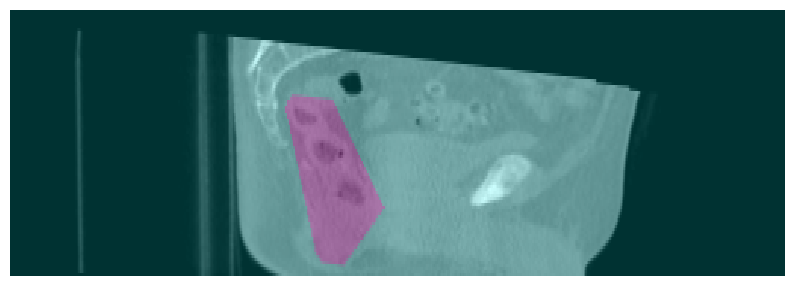

In [26]:
# display a random image with mask overlayed in transparent blue using seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# set the image and mask number by choosing a random index
idx = np.random.randint(0,len(augmented_train_df))
image = augmented_train_df['images'][idx]
mask = augmented_train_df['masks'][idx]

# create a figure
fig, ax = plt.subplots(1,1,figsize=(10,10))

# modify the y axis tics to only show every 10th tic

sns.heatmap(image, ax=ax, cmap='gray', cbar=False) # hide the colorbar
sns.heatmap(mask, ax=ax, cmap='cool', alpha=0.2, cbar=False)

# hide the axis
ax.axis('off')

#scale the y axis by 0.5
ax.set_aspect(2)

plt.show()

In [27]:
# convert masks to uint8 and images to float32
augmented_train_df['masks'] = augmented_train_df['masks'].apply(lambda x: x.astype(np.uint8))
augmented_train_df['images'] = augmented_train_df['images'].apply(lambda x: x.astype(np.float32))

## The AI Training algorithm

### Loss functions tested

 - **BCELoss** - poor results - discarded
 - **BCEWithLogits** - on GPU using U-Net model  - best results

In [29]:
# first ensure that torch is running on the GPU
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"HIP version: {torch.version.hip}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name()}")
    print(f"Device count: {torch.cuda.device_count()}")
    memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Device memory: {memory:.2f} GB")


PyTorch version: 2.7.0.dev20250306+rocm6.3
Is CUDA available? True
HIP version: 6.3.42131-fa1d09cbd
Current device: 0
Device name: Radeon RX 7900 XTX
Device count: 1
Device memory: 25.75 GB


### Edit as appropriate (use_pretrained_model = True, filename) if using a pretrained model

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

use_pretrained_model = True
# use_pretrained_model = False
filename = 'model_rectum.pth'

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)
        self.bottleneck = self.conv_block(512, 1024)
        self.upconv4 = self.upconv(1024, 512)
        self.decoder4 = self.conv_block(1024, 512)
        self.upconv3 = self.upconv(512, 256)
        self.decoder3 = self.conv_block(512, 256)
        self.upconv2 = self.upconv(256, 128)
        self.decoder2 = self.conv_block(256, 128)
        self.upconv1 = self.upconv(128, 64)
        self.decoder1 = self.conv_block(128, 64)
        self.conv_last = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(F.max_pool2d(enc1, 2))
        enc3 = self.encoder3(F.max_pool2d(enc2, 2))
        enc4 = self.encoder4(F.max_pool2d(enc3, 2))
        bottleneck = self.bottleneck(F.max_pool2d(enc4, 2))
        dec4 = self.upconv4(bottleneck)
        # dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.pad_and_concat(dec4, enc4)
        dec4 = self.decoder4(dec4)
        dec3 = self.upconv3(dec4)
        # dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.pad_and_concat(dec3, enc3)
        dec3 = self.decoder3(dec3)
        dec2 = self.upconv2(dec3)
        # dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.pad_and_concat(dec2, enc2)
        dec2 = self.decoder2(dec2)
        dec1 = self.upconv1(dec2)
        # dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.pad_and_concat(dec1, enc1)
        dec1 = self.decoder1(dec1)
        return self.conv_last(dec1)
    
    def pad_and_concat(self, upsampled, bypass):
        diffY = bypass.size()[2] - upsampled.size()[2]
        diffX = bypass.size()[3] - upsampled.size()[3]
        upsampled = F.pad(upsampled, [diffX // 2, diffX - diffX // 2,
                                      diffY // 2, diffY - diffY // 2])
        return torch.cat([upsampled, bypass], dim=1)
    
class ImageDataset(Dataset):
    def __init__(self, images, masks):

        # convert pandas series to single numpy array
        if isinstance(images, pd.Series):
            images = np.stack(images.values)
        if isinstance(masks, pd.Series):
            masks = np.stack(masks.values)
            
        self.images = torch.tensor(images, dtype=torch.float32).unsqueeze(1) 
        self.masks = torch.tensor(masks, dtype=torch.uint8).unsqueeze(1)
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx].float()

if use_pretrained_model:
    model = UNet(in_channels=1, out_channels=1).to(device)
    if torch.cuda.is_available():
        model.load_state_dict(torch.load(filename))
    else:
        model.load_state_dict(torch.load(filename, map_location=torch.device('cpu')))

    criterion = nn.BCEWithLogitsLoss()
    # model.eval()
    # test_dataset = ImageDataset(val_images, val_masks)
    # test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)
else:
    # Initialize model
    model = UNet(in_channels=1, out_channels=1).to(device)
    # Adjust Hyperparameters
    learning_rate = 1e-4
    num_epochs = 25
    batch_size = 32
    # Initialize model and optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    # criterion = combined_loss
    criterion = nn.BCEWithLogitsLoss()

    # Create data loaders
    train_dataset = ImageDataset(augmented_train_df['images'], augmented_train_df['masks'])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        for batch_idx, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device) # move to GPU
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
        
            if batch_idx % 10 == 0:
                print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item():.4f}')

Using device: cuda


In [ ]:
# Save the model
# torch.save(model.state_dict(), 'model_rectum.pth')

### Post processing

- To reduce the number of spurious artifacts, post process the predictions to return the largest connected region
    - only possible on GPU
- Finally check the accuracy of the predictions by comparing to the known masks derived from the contours

In [31]:
# Validation
model.eval()
val_dataset = ImageDataset(val_df['images'], val_df['masks'])
val_loader = DataLoader(val_dataset, batch_size=1)
val_loss = 0
val_masks_pred = []

with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, masks)
        val_loss += loss.item()

        # generate predictions
        predictions = torch.sigmoid(outputs)
        val_masks_pred.append(predictions.cpu().numpy())

# Compute average validation loss
val_loss_avg = val_loss / len(val_loader) * 100
print(f'Validation Loss: {val_loss_avg:.2f}%')

# Concatenate predictions
val_masks_pred = np.concatenate(val_masks_pred, axis=0)
print(f"Validation predictions shape: {val_masks_pred.shape}")



Validation Loss: 0.39%
Validation predictions shape: (447, 1, 88, 512)


In [32]:
# set cutoff threshold
threshold = 0.5
val_masks_pred_binary = val_masks_pred > threshold

print(f"Validation predicitons shape: {val_masks_pred.shape}")
print(f"Validation predictions binary shape: {val_masks_pred_binary.shape}")


Validation predicitons shape: (447, 1, 88, 512)
Validation predictions binary shape: (447, 1, 88, 512)


In [33]:
# calculate the Dice coefficient for the validation set

def dice_coefficient(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred)
    if union == 0:
        return 1
    else:
        return 2 * intersection / union
    
dice_scores = []
for true, pred in zip(val_df['masks'], val_masks_pred_binary):
    dice_scores.append(dice_coefficient(true, pred))

print(f"Average Dice coefficient: {np.mean(dice_scores):.4f}")
print(f"Standard deviation: {np.std(dice_scores):.4f}")

Average Dice coefficient: 0.9607
Standard deviation: 0.1110


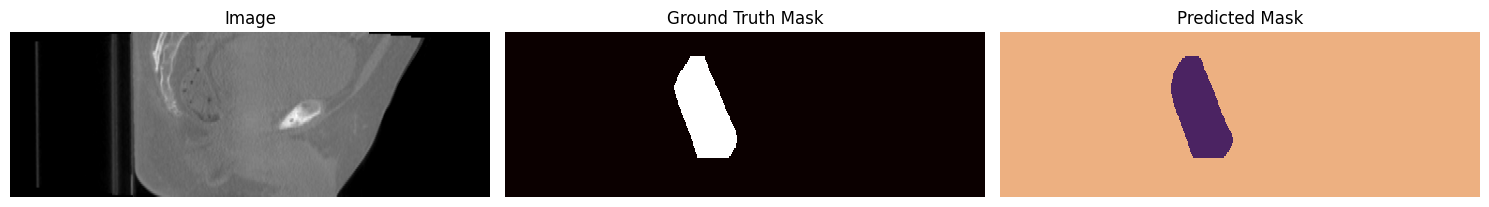

In [42]:
# Display the results
fig, ax = plt.subplots(1, 3, figsize=(15, 10))

# Choose a random patient
rnd_pat = np.random.randint(0, len(val_df))

# sns.heatmap(X_val[rnd_pat], ax=ax[0], cmap='gray', cbar=False)
ax[0].imshow(val_df['images'].iloc[rnd_pat], cmap='gray')
ax[0].set_title('Image')
ax[0].axis('off')

# Display the true mask
sns.heatmap(val_df['masks'].iloc[rnd_pat], ax=ax[1], cmap='hot', cbar=False)
ax[1].set_title('Ground Truth Mask')
ax[1].axis('off')

# Display the predicted mask - remove the extra dimension with squeeze
# use cmap 'cool' for bladder, 'viridis' for prostate and 'rainbow' for rectum
sns.heatmap(val_masks_pred_binary[rnd_pat].squeeze(), ax=ax[2], cmap='flare', cbar=False)
ax[2].set_title('Predicted Mask')
ax[2].axis('off')

for a in ax:
    a.set_aspect(2)

plt.tight_layout()
plt.show()

Dimensions of val_masks: (88, 512)
Dimensions of val_masks_pred_binary: (1, 88, 512)


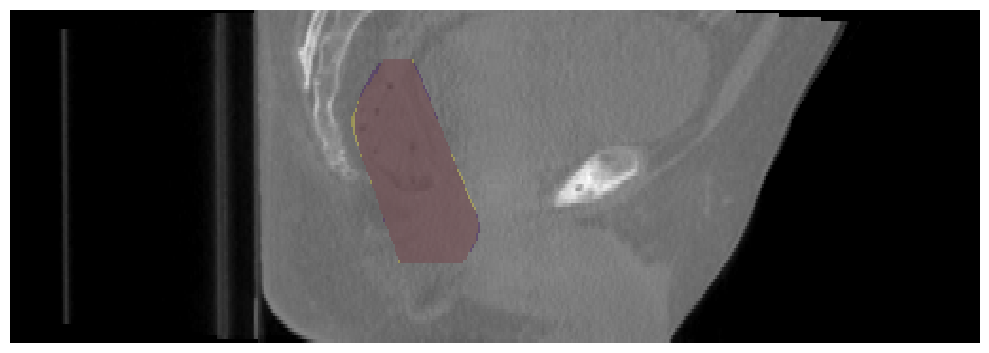

In [43]:
# rather than drawing three images, I want the image with the mask and the predicted mask overlayed with transparency in different colors, so that the overlap is visible
# I will use the seaborn heatmap function to do this

fig, ax = plt.subplots(1, 1, figsize=(10, 20))
# rnd_pat = np.random.randint(len(val_images))

# Base Layer: image slice
sns.heatmap(val_df['images'].iloc[rnd_pat], ax=ax, cmap='gray', cbar=False)

print(f"Dimensions of val_masks: {val_df['masks'].iloc[rnd_pat].shape}")
print(f"Dimensions of val_masks_pred_binary: {val_masks_pred_binary[rnd_pat].shape}")

# Middle Layer: Overlay the true mask 
cmask_zeros = val_df['masks'].iloc[rnd_pat] == 0
alpha = np.ones_like(val_df['masks'].iloc[rnd_pat], dtype=float) * 0.3
alpha[cmask_zeros] = 0.0
sns.heatmap(val_df['masks'].iloc[rnd_pat]/2.0, ax=ax, cmap='viridis', alpha=alpha, cbar=False)

# Top Layer: overlay the predicted mask in blue
vmask_zeros = val_masks_pred_binary[rnd_pat].squeeze() == 0
alpha = np.ones_like(val_masks_pred_binary[rnd_pat].squeeze(), dtype=float) * 0.5
alpha[vmask_zeros] = 0.0
sns.heatmap(val_masks_pred_binary[rnd_pat].squeeze(), ax=ax, cmap='flare', alpha=alpha, cbar=False)

ax.set_aspect(2)
ax.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
# estimate the rectum fill volume, using a cylinder model
# The pixel dimensions are 0.908 mm x 0.908 mm, and the slice thickness is 1.988 mm

# use height and width of mask, multiply by physical dimensions, use volume of cylinder

def vol_cylinder(width,height):
    r = width/2 # semi-major axis
    vol = np.pi * r**2 * height
    return vol

# calculate the volume of the rectum for rnd_pat
mask = val_df['masks'].iloc[rnd_pat]

# find the max width and max height of the positive pixels in the mask
y,x = np.where(mask)
width_pixel = x.max() - x.min()
height_pixel = y.max() - y.min()

# calculate the volume
vol = vol_cylinder(width_pixel*0.908, height_pixel*1.988)
vol_L = vol / 1e3

print(f"Estimated rectal volume: {vol_L:.2f} ml")


Estimated rectal volume: 297.20 L


## **6. Conclusions**

- Basic Neural Net running on CPU produces impressive results
- Many options to improve prediction quality
    1. Better acquisition parameters:
        - stardardized CBCT dimensions and ROI
    2. Training algorithm improvements on GPU with more Epochs, tweaked loss function and hyperparameters
- Define function for calculating estimate of bladder fill
- Repeat procedures for rectum and perhaps other stuctures


To Do 
- compare areas of planungs-CT area and calculated area / bladder 1/2, 2/3, 